# Netflix Content Analysis

## Project Overview
This project analyzes Netflix's content dataset to understand patterns in the platform's library.

The goal is to explore:

• Distribution of Movies vs TV Shows  
• Growth of Netflix content over time  
• Top countries producing Netflix content  
• Most common genres  
• Rating distribution of content  

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

## Dataset Source
Kaggle - Netflix Movies and TV Shows Dataset

## Dataset Description

The dataset contains information about Netflix titles including:

• show_id – Unique identifier  
• type – Movie or TV Show  
• title – Title of the content  
• director – Director of the content  
• cast – Cast members  
• country – Country of production  
• date_added – Date the title was added to Netflix  
• release_year – Year the content was released  
• rating – Age rating of the content  
• duration – Duration of the content  
• listed_in – Genre categories  
• description – Short summary of the content

Step 1 - Project Title (Markdown Cell)

# Netflix Data Analysis Project

This project analyzes Netflix's content library to understand:
- Distribution of Movies vs TV Shows
- Content growth over time
- Top countries producing Netflix content
- Most common genres
- Rating distribution

Tools used:
- Python
- Pandas
- Matplotlib
- Seaborn

Step 2 - Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step 3 - Load Dataset

In [11]:
df=pd.read_csv("netflix_titles.csv")

Step 4 - View Dataset

In [12]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Step 5 - Basic Dataset Information

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [15]:
df.shape

(8807, 12)

In [16]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Step 6 - Check Missing Values

In [52]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      10
dtype: int64

Step 7 - Data Cleaning

In [25]:
# Fill Missing Values
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df["rating"].fillna("Not Rated")

In [47]:
# Convert date column
# df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="%B %d, %Y")
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [50]:
# Create new column year_added
df['year_added'] = df['date_added'].dt.year

In [54]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


Step 8 - Movies vs TV Shows Analysis

In [57]:
# Check Counts
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Text(0.5, 1.0, 'Movies vs TV Shows on Netflix')

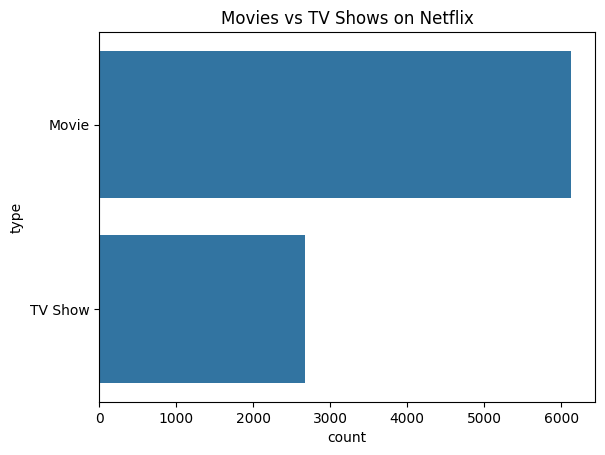

In [61]:
# visualization
sns.countplot(y=df['type'])
plt.title("Movies vs TV Shows on Netflix")

Step 9 - Content Added Each Year

Text(0.5, 1.0, 'Content Added to Netflix Each Year')

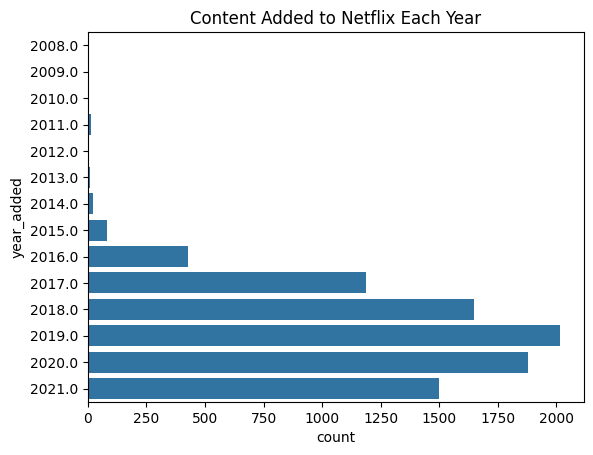

In [65]:
df['year_added'].value_counts().sort_index()

sns.countplot(y=df['year_added'])
plt.title("Content Added to Netflix Each Year")

Step 10 - Top Countries Producing Content

Text(0.5, 1.0, 'Top 10 Countries Producing Netflix Content')

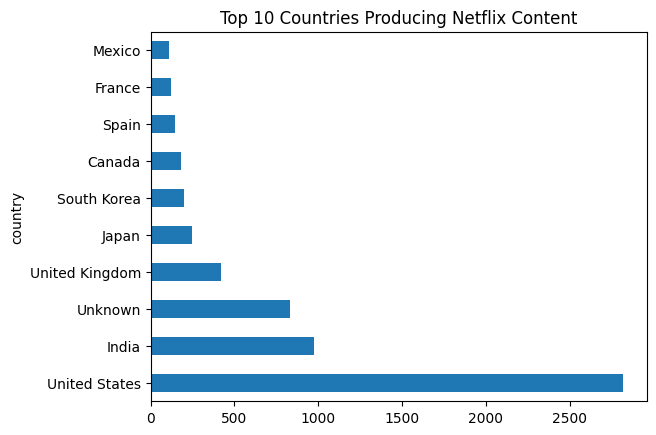

In [77]:
top_country = df['country'].value_counts().head(10)
top_country.plot(kind='barh')
plt.title("Top 10 Countries Producing Netflix Content")

Step 11 - Rating Distribution

Text(0.5, 1.0, 'Netflix Content Ratings')

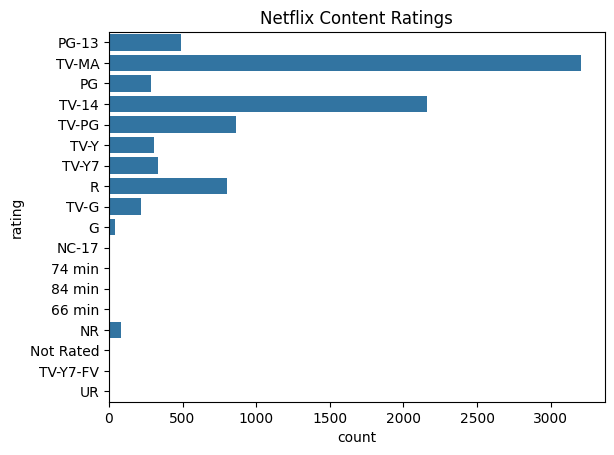

In [82]:
sns.countplot(y=df['rating'])
plt.title("Netflix Content Ratings")

Step 12 - Most Common Genres

Text(0.5, 1.0, 'Top 10 Most Common Netflix Genres')

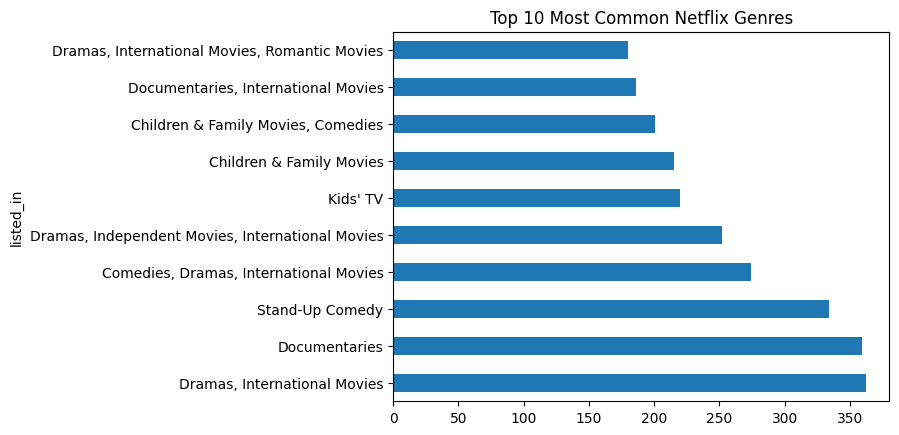

In [88]:
df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Most Common Netflix Genres")

Step 13 - Write Insights (Markdown Cell)

## Key Insights

1. Netflix has significantly more Movies than TV Shows.
2. Content production increased rapidly after 2016.
3. The United States produces the most Netflix content.
4. Drama and Comedy are among the most common genres.
5. TV-MA is one of the most common ratings on Netflix.

In [89]:
df["rating"].nunique()

18